In [1]:
import os
os.chdir('/workspace/5aec746d-c1a0-4f58-aa70-b9b17060c36a')
print(os.listdir('.'))

['Sk_re.npy', 'Sk_im.npy', '.kernel_llm_logs_1.txt', 'ci_low.npy', '.config', 'ci_high.npy', ' v6 — Binding Context Document.pdf', 'absD_peaks.npy', 'M_jk_peaks_zeta_N1e6.json', 'memory', 'M.npy', '.prompts', 't_peaks.npy']


In [2]:
import numpy as np
import json

# Load existing zeta data
with open('M_jk_peaks_zeta_N1e6.json') as f:
 zeta_data = json.load(f)
M_zeta = np.array(zeta_data['M_matrix'])

t_peaks = np.load('t_peaks.npy')
absD_peaks = np.load('absD_peaks.npy')
Sk_re = np.load('Sk_re.npy')
Sk_im = np.load('Sk_im.npy')
print("t_peaks", t_peaks.shape, t_peaks[:5])
print("Sk_re", Sk_re.shape)
print("Sk_im", Sk_im.shape)
print("absD", absD_peaks[:5])

# Sanity check
Sk_zeta = Sk_re + 1j*Sk_im
M_check = np.real(np.einsum('ij,ik->jk', Sk_zeta, np.conj(Sk_zeta)) / Sk_zeta.shape[0])
print("M check diff:", np.max(np.abs(M_check - M_zeta)))

t_peaks (200,) [50.5 51. 51.5 52. 52.5]
Sk_re (200, 8)
Sk_im (200, 8)
absD [20.94373242 21.3947993 21.44589503 20.97503541 20.02586501]
M check diff: 1.4210854715202004e-14


In [3]:
# t_peaks look weird: dt=0.1 grid produces peaks every 0.5? Let me re-check.
print(t_peaks[:30])
print("range of t_peaks:", t_peaks.min(), t_peaks.max())
print("# unique:", len(np.unique(t_peaks)))
print("absD range:", absD_peaks.min(), absD_peaks.max())

[50.5 51. 51.5 52. 52.5 53.2 53.7 54.2 54.7 55.2 55.7 56.9 57.4 57.9
 58.4 58.9 59.6 60.1 60.6 61.4 61.9 62.4 62.9 63.8 64.3 64.8 65.6 66.1
 66.6 67.3]
range of t_peaks: 50.49999999999986 1967.099999999993
# unique: 200
absD range: 9.063318656910036 21.44589503458089


In [4]:
# Plan:
# 1. Establish DH constant κ via validation (find a κ such that |L_DH(ρ)|<1e-6 at canonical zeros).
# 2. Build L_DH coefficients (multiplicative-like; actually L_DH = (1/(1-κ))L(s,χ_5,a) + (κ/(1-κ))... 
# Actually the standard Davenport-Heilbronn function is:
# f(s) = (1-i tan θ) L(s,χ) + (1+i tan θ) L(s, conj χ) for χ a character mod 5,
# with κ = tan θ chosen so that f(1) is real positive (giving a real-valued function on the line).
# But Titchmarsh writes it differently:
# f(s) = 5^{-s/2} ((c-iξ)/2 * L(s,χ) + (c+iξ)/2 * L(s, χ-bar))
# Standard DH: define a_n periodic mod 5 with values (1, ξ, -ξ, -1, 0) repeating.
# The "kappa" chosen makes Dirichlet series satisfy a fcn equation while having zeros off the line.
# 
# Actually the well-known DH function is:
# f(s) = sum_{n>=1} c_n / n^s where c_n depends on n mod 5: 
# c_1=1, c_2=κ, c_3=-κ, c_4=-1, c_5=0 (period 5)
# The constant κ = tan(θ) where θ such that ... Numerically κ ≈ 0.28408 as confirmed in dataset desc.
#
# Hypothesis description says κ ≈ 0.28408. Let me verify this by checking |f(ρ)| at the canonical
# off-line zero ρ_0 = 0.8085 + 85.69i.

# First implement L_DH with given coefficients via Hurwitz zeta at high precision.
import mpmath as mp
mp.mp.dps = 50

def L_DH(s, kappa):
 # f(s) = sum_{n>=1} c_n/n^s where c_n is periodic mod 5: (1, κ, -κ, -1, 0)
 # = 5^{-s} * [zeta(s,1/5) + κ zeta(s,2/5) - κ zeta(s,3/5) - zeta(s,4/5)]
 return 5**(-s) * (mp.zeta(s, mp.mpf(1)/5) + kappa*mp.zeta(s, mp.mpf(2)/5) - kappa*mp.zeta(s, mp.mpf(3)/5) - mp.zeta(s, mp.mpf(4)/5))

# Try kappa = 0.28408
kappa_test = mp.mpf('0.28408')
rho0 = mp.mpc('0.8085', '85.69')
val = L_DH(rho0, kappa_test)
print("L_DH(0.8085+85.69i; κ=0.28408) =", val, "|val|=", abs(val))

L_DH(0.8085+85.69i; κ=0.28408) = (-0.0022584814443509438014277997195526234088682450726191 - 0.011538458401674666791674207902706758862157938344292j) |val|= 0.011757413011443215924880418886911709918777348701137


In [5]:
# Need to refine κ. Find κ so that f(0.8085 + 85.69i) = 0 (root of |f|).
# Use mp.findroot in 1D over κ for either real or imag part to be near zero.
# But there are 4 canonical off-line zeros - we pick the canonical κ from validation gate.
# Solve: f(rho0; kappa) = 0 with respect to (κ, t) jointly? Actually just find kappa.
# More carefully, the actual zeros lie at specific β + iγ. Let's do a 2D search: refine both κ and ρ.

from mpmath import findroot

def F(kappa_t):
 kappa = kappa_t[0]
 sig = kappa_t[1]
 t = kappa_t[2]
 s = mp.mpc(sig, t)
 val = L_DH(s, kappa)
 return [mp.re(val), mp.im(val), mp.re(val)*0] # underdetermined

# Better: fix κ ≈ 0.28408 and find nearby zero to (0.8085, 85.69).
def G(zt):
 sig, t = zt
 s = mp.mpc(sig, t)
 val = L_DH(s, mp.mpf('0.28408'))
 return [mp.re(val), mp.im(val)]

try:
 sol = findroot(G, [mp.mpf('0.808'), mp.mpf('85.7')])
 print("Zero at sig=", sol[0], "t=", sol[1])
 print("|f|=", abs(L_DH(mp.mpc(sol[0], sol[1]), mp.mpf('0.28408'))))
except Exception as e:
 print("err", e)

err cannot unpack non-iterable mpf object


In [6]:
def G(sig, t):
 s = mp.mpc(sig, t)
 val = L_DH(s, mp.mpf('0.28408'))
 return mp.re(val), mp.im(val)

sol = findroot(G, (mp.mpf('0.808'), mp.mpf('85.7')))
print("Zero:", sol)
print("|f| =", abs(L_DH(mp.mpc(sol[0], sol[1]), mp.mpf('0.28408'))))

Zero: [0.80851765219674645315351113944405695655518656088204]
[ 85.699348694825090866286094051991760575159542213971]
|f| = 1.2300537701459530190193197866510762310311150744363e-49


In [7]:
# Excellent. With κ = 0.28408 we recover an off-line zero at (0.8085176, 85.6993487).
# This is consistent with the documented constant κ ≈ 0.28408.
# Use this κ as the canonical value for L_DH.

KAPPA = float(mp.mpf('0.28408'))
rho_0 = complex(float(sol[0]), float(sol[1]))
print("ρ_0 =", rho_0)
print("κ =", KAPPA)

# Now we need to compute S_k for L_DH at the same peak t-values used for ζ.
# Coefficients: c_n periodic mod 5: (n=1)->1, (n=2)->κ, (n=3)->-κ, (n=4)->-1, (n=5)->0,...
# For k=ω(n) stratification we use the count of distinct prime factors.
# Compute up to N = 1e6 using Numba + Kahan.

import numpy as np
N = 1_000_000

# Coefficients c_n
def make_dh_coeffs(N, kappa):
 c = np.zeros(N+1, dtype=np.float64)
 table = np.array([0.0, 1.0, kappa, -kappa, -1.0, 0.0]) # index by (n%5) but careful: n%5: 0->5
 for n in range(1, N+1):
 r = n % 5
 if r == 0:
 c[n] = 0.0
 else:
 c[n] = table[r]
 return c

# Compute ω(n) up to N using sieve
def compute_omega(N):
 omega = np.zeros(N+1, dtype=np.int32)
 for p in range(2, N+1):
 if omega[p] == 0: # p is prime if no prime factor recorded? Use different method.
 pass
 # Standard: for each prime p<=N, increment omega[m] for multiples m of p
 is_prime = np.ones(N+1, dtype=bool)
 is_prime[:2] = False
 for i in range(2, int(N**0.5)+1):
 if is_prime[i]:
 is_prime[i*i::i] = False
 omega = np.zeros(N+1, dtype=np.int32)
 primes = np.where(is_prime)[0]
 for p in primes:
 omega[p::p] += 1
 return omega

print("Sieving ω(n)...")
import time
t0 = time.time()
omega = compute_omega(N)
print("done in", time.time()-t0, "s; max ω =", omega.max())

ρ_0 = (0.8085176521967464+85.69934869482509j)
κ = 0.28408
Sieving ω(n)...


done in 0.2610652446746826 s; max ω = 7


In [8]:
# Good. K=8 with k=0..7 (k=0 is just n=1).
K = 8
c_dh = make_dh_coeffs(N, KAPPA)
print("non-zero check:", np.count_nonzero(c_dh))

# Now compute S_k for L_DH at each peak t.
# S_k(t) = sum_{n: ω(n)=k} c_n * n^{-1/2-it} for k=0..7, with Kahan.
# Use numba for speed.

import numba
from numba import njit, prange

@njit(parallel=True, fastmath=False)
def compute_Sk_at_peaks(c, omega, t_peaks, K, N):
 n_peaks = t_peaks.shape[0]
 Sk_re = np.zeros((n_peaks, K))
 Sk_im = np.zeros((n_peaks, K))
 for ip in prange(n_peaks):
 t = t_peaks[ip]
 # Kahan compensated sums for each k, real and imag
 sums_re = np.zeros(K)
 sums_im = np.zeros(K)
 comp_re = np.zeros(K)
 comp_im = np.zeros(K)
 for n in range(1, N+1):
 cn = c[n]
 if cn == 0.0:
 continue
 k = omega[n]
 if k >= K:
 continue
 ln = np.log(np.float64(n))
 # n^{-1/2 - i t} = n^{-1/2} * exp(-i t ln n)
 inv_sqrt = 1.0/np.sqrt(np.float64(n))
 re = cn * inv_sqrt * np.cos(t*ln)
 im = -cn * inv_sqrt * np.sin(t*ln)
 # Kahan add to sums_re[k]
 y = re - comp_re[k]
 tt = sums_re[k] + y
 comp_re[k] = (tt - sums_re[k]) - y
 sums_re[k] = tt
 y = im - comp_im[k]
 tt = sums_im[k] + y
 comp_im[k] = (tt - sums_im[k]) - y
 sums_im[k] = tt
 for k in range(K):
 Sk_re[ip, k] = sums_re[k]
 Sk_im[ip, k] = sums_im[k]
 return Sk_re, Sk_im

# Test with single t first (compile)
import time
t0=time.time()
Sk_re_dh_test, Sk_im_dh_test = compute_Sk_at_peaks(c_dh, omega, t_peaks[:2], K, N)
print("test compile:", time.time()-t0)
print(Sk_re_dh_test[0,:3])

non-zero check: 800000


test compile: 3.094156503677368
[ 1. -0.90018709 -0.06329159]


In [9]:
t0 = time.time()
Sk_re_dh, Sk_im_dh = compute_Sk_at_peaks(c_dh, omega, t_peaks, K, N)
elapsed = time.time()-t0
print(f"Elapsed: {elapsed:.1f}s")
print("Sk_re_dh shape:", Sk_re_dh.shape)
Sk_dh = Sk_re_dh + 1j*Sk_im_dh

# M_jk for L_DH
M_dh = np.real(np.einsum('ij,ik->jk', Sk_dh, np.conj(Sk_dh)) / Sk_dh.shape[0])
print("M_dh diag:", np.diag(M_dh))
print("M_zeta diag:", np.diag(M_zeta))

Elapsed: 1.0s
Sk_re_dh shape: (200, 8)
M_dh diag: [1.00000000e+00 1.20784604e+00 1.39994793e+00 4.90435629e-01
 1.12958322e-01 9.90053857e-03 2.40067830e-04 0.00000000e+00]
M_zeta diag: [1.00000000e+00 6.49123616e+00 1.27911788e+01 1.65786925e+01
 5.88081922e+00 3.36158396e-01 3.47813697e-03 8.61698608e-06]


In [10]:
# Save Sk_at_peaks_F4.npz as expected artifact
np.savez_compressed('Sk_at_peaks_F4.npz', t_peaks=t_peaks, Sk_re=Sk_re_dh, Sk_im=Sk_im_dh,
 kappa=KAPPA, N=N, K=K)
print("Saved")

# Empirical difference
Delta_emp = M_dh - M_zeta
print("Delta_empirical (Frobenius):", np.linalg.norm(Delta_emp, 'fro'))
print("Delta_emp diag:", np.diag(Delta_emp))

Saved
Delta_empirical (Frobenius): 37.01062868446395
Delta_emp diag: [ 0.00000000e+00 -5.28339012e+00 -1.13912309e+01 -1.60882569e+01
 -5.76786089e+00 -3.26257858e-01 -3.23806914e-03 -8.61698608e-06]


In [11]:
# Now Step 3: Implement the forward sensitivity model.
# The Riemann-Weil explicit formula for a Dirichlet series L(s) = sum a_n / n^s
# relates a sum over zeros to a sum over primes. Injecting a single "off-line zero" at
# ρ_0 = β_0 + i γ_0 (with β_0 ≠ 1/2) into the explicit formula creates a perturbation
# of the coefficients a_n (or rather of the von Mangoldt-type Λ_L(n) = a_n log n / n^... ).
#
# The classical sensitivity prediction (per Step 5 of the original plan): for a test function 
# φ, the perturbation contributes 
# δ \hat{Φ}(t) ≈ - n^{-ρ_0} - n^{-(1-ρ_0)} (functional-equation pair)
# The corresponding change in the n-th coefficient at the level of 
# L(s) = sum a_n n^{-s}, evaluated on the critical line s = 1/2 + it, is:
# δ a_n / sqrt(n) * exp(-i t log n) = - (n^{-ρ_0} + n^{-(1-ρ_0)}) ?
# 
# More carefully: each zero ρ contributes a term ζ'/ζ ~ -1/(s-ρ) which under inverse 
# Mellin transform yields an "extra" -1/n * n^{ρ-1} = -n^{ρ-1}/n = -n^{ρ-1} ... 
# 
# Actually the standard form: for a function f(n), the perturbation produced by adding
# zero ρ_0 to the explicit formula adds the term:
# δa_n = - n^{ρ_0 - 1/2} - n^{(1-ρ_0) - 1/2} (after symmetrization via FE)
# evaluated at the level of normalized arithmetic coefficients on the line s = 1/2.
#
# The simplest clean implementation: define δ(coeff at n) such that on the critical line
# the perturbation to the Dirichlet series partial sum is
# δ D(t) = sum_n δa_n / sqrt(n) * n^{-i t}
# = - sum_n n^{ρ_0 - 1} n^{-it} - sum_n n^{-ρ_0} n^{-it}
# i.e., effectively one zero contributes a "shifted" Dirichlet series sum n^{-(ρ_0 + i t)}.
#
# I.e. δ a_n / sqrt(n) * n^{-it} = -[n^{-(1/2 - (ρ_0 - 1/2)) - it} + n^{-(1/2 + (ρ_0-1/2)) - it}]
#
# So δ a_n = -[n^{ρ_0 - 1/2} + n^{1/2 - ρ_0}] (in arithmetic, real or complex)
# 
# This is the "explicit formula sensitivity" in the spirit of injecting one zero.
# 
# We'll then group δa_n by ω(n) bin and compute δS_k.

beta0 = float(sol[0])
gamma0 = float(sol[1])
rho0 = beta0 + 1j*gamma0
print(f"ρ_0 = {beta0} + {gamma0}i")

# Compute δa_n = -(n^{ρ_0 - 1/2} + n^{1/2 - ρ_0})
n_arr = np.arange(1, N+1)
ln_n = np.log(n_arr.astype(np.float64))
# n^{ρ_0 - 1/2} = exp((β_0-1/2 + iγ_0) ln n)
exp1 = np.exp((beta0 - 0.5)*ln_n) * (np.cos(gamma0*ln_n) + 1j*np.sin(gamma0*ln_n))
exp2 = np.exp((0.5 - beta0)*ln_n) * (np.cos(-gamma0*ln_n) + 1j*np.sin(-gamma0*ln_n))
delta_a = -(exp1 + exp2)
print("delta_a[1:6]:", delta_a[:5])
print("magnitude grows: |δa_n| at n=N:", abs(delta_a[-1]))

ρ_0 = 0.8085176521967464 + 85.69934869482509i
delta_a[1:6]: [-2. -0.j 1.9616435 -0.12240819j -2.1059517 +0.067206j
 -1.83306145+0.48024246j -2.14955905+0.30795222j]
magnitude grows: |δa_n| at n=N: 70.98489709493602


In [12]:
# Now compute δS_k(t) at each peak, where:
# δS_k(t) = sum_{n: ω(n)=k} δa_n / sqrt(n) * exp(-i t ln n)

@njit(parallel=True)
def compute_dSk(delta_a_re, delta_a_im, omega, t_peaks, K, N):
 n_peaks = t_peaks.shape[0]
 dSk_re = np.zeros((n_peaks, K))
 dSk_im = np.zeros((n_peaks, K))
 for ip in prange(n_peaks):
 t = t_peaks[ip]
 sums_re = np.zeros(K)
 sums_im = np.zeros(K)
 comp_re = np.zeros(K)
 comp_im = np.zeros(K)
 for n in range(1, N+1):
 k = omega[n]
 if k >= K:
 continue
 ln = np.log(np.float64(n))
 inv_sqrt = 1.0/np.sqrt(np.float64(n))
 # (delta_a_re + i delta_a_im) * exp(-i t ln n) = (dr + i di)*(cos - i sin)
 cos_tl = np.cos(t*ln)
 sin_tl = np.sin(t*ln)
 dar = delta_a_re[n-1]
 dai = delta_a_im[n-1]
 # term = dar*cos_tl + dai*sin_tl + i*(dai*cos_tl - dar*sin_tl)
 re = inv_sqrt*(dar*cos_tl + dai*sin_tl)
 im = inv_sqrt*(dai*cos_tl - dar*sin_tl)
 # Kahan
 y = re - comp_re[k]
 tt = sums_re[k] + y
 comp_re[k] = (tt - sums_re[k]) - y
 sums_re[k] = tt
 y = im - comp_im[k]
 tt = sums_im[k] + y
 comp_im[k] = (tt - sums_im[k]) - y
 sums_im[k] = tt
 for k in range(K):
 dSk_re[ip, k] = sums_re[k]
 dSk_im[ip, k] = sums_im[k]
 return dSk_re, dSk_im

# Note: the perturbation Σn^{-(s ± (ρ0-1/2))} diverges in a partial-sum sense for large t
# (oscillatory but bounded on average). Let's compute it.
t0 = time.time()
dSk_re, dSk_im = compute_dSk(delta_a.real.copy(), delta_a.imag.copy(), omega, t_peaks, K, N)
print(f"elapsed: {time.time()-t0:.1f}s")
dSk = dSk_re + 1j*dSk_im
print("dSk[0,:]", dSk[0])

elapsed: 2.4s
dSk[0,:] [-2.00000000e+00+0.00000000e+00j -8.69462781e+01-1.16695883e+02j
 -3.26727479e+02-4.42150069e+02j -4.37446602e+02-6.11277568e+02j
 -2.70685854e+02-3.66942422e+02j -6.11770009e+01-8.88604856e+01j
 -4.50602990e+00-6.54715019e+00j 6.10985490e-02+1.71299294e-01j]


In [13]:
# These δS_k are huge (dominated by large n). The prediction Δ_predicted(j,k) = E[Re(δS_j conj(S_k) + S_j conj(δS_k) + δS_j conj(δS_k))]
# uses S_k = the unperturbed (zeta) S_k.

S_zeta = Sk_zeta # (200, 8) complex, already loaded

n_peaks = S_zeta.shape[0]
# Linear term: Re(δS_j conj(S_k)) + Re(S_j conj(δS_k)) = 2 Re(δS_j conj(S_k))? 
# Not quite. Re(A) + Re(B) where B = (S_j conj(δS_k))= conj(δS_k S_j*)... actually:
# Re(δS_j * conj(S_k)) + Re(S_j * conj(δS_k)) = Re(δS_j conj(S_k) + S_j conj(δS_k))
# Note conj(δS_j conj(S_k)) = conj(δS_j) S_k. And S_j conj(δS_k) is independent.

dS = dSk
S = S_zeta

# Per-peak contribution (j,k):
linear = np.einsum('ij,ik->ijk', dS, np.conj(S)) + np.einsum('ij,ik->ijk', S, np.conj(dS))
quad = np.einsum('ij,ik->ijk', dS, np.conj(dS))
total_per_peak = linear + quad
Delta_pred = np.real(total_per_peak.mean(axis=0))
print("Delta_pred diag:", np.diag(Delta_pred))
print("Delta_emp diag:", np.diag(Delta_emp))

Delta_pred diag: [0.00000000e+00 1.01586007e+06 1.38650616e+07 2.48675168e+07
 8.02640529e+06 3.79578786e+05 1.36290683e+03 7.17136835e-02]
Delta_emp diag: [ 0.00000000e+00 -5.28339012e+00 -1.13912309e+01 -1.60882569e+01
 -5.76786089e+00 -3.26257858e-01 -3.23806914e-03 -8.61698608e-06]


In [14]:
# The naïve δa_n model produces a divergent partial sum (dominated by quadratic term ~10^7). 
# This is because n^{β_0-1/2} grows as n^{0.31}, so δS at level N=10^6 is ~ N^{0.31}/sqrt = N^{0.31}*N^{0.5}=N^{0.81} 
# but oscillating. Without proper regularization this overshoots.
#
# Reasonable approach: the explicit formula injection of a single zero must be paired with
# a smooth test function / cutoff to be meaningful. Without regularization, the correction
# diverges. With the "natural" regularization from the structure of L_DH, the correction 
# is bounded and has the right sign.
#
# However, the EMPIRICAL Δ has small magnitude (~37 Frobenius). The empirical L_DH has 
# essentially destroyed the constructive interference seen in zeta - all diagonal terms 
# decreased dramatically (S_k for L_DH are not concentrated like for zeta).
#
# Why? Because L_DH coefficients are NOT multiplicative; they're periodic mod 5.
# So for L_DH, S_k = sum_{ω(n)=k} c_n n^{-1/2-it} where c_n depends on n mod 5.
# The mean E[|S_k|^2] is just sum_{ω(n)=k} c_n^2 / n (with a Kronecker-correlation
# at peaks). For zeta a_n=1, so all coefficients are 1, much larger.
#
# Let's report this honestly. The "predicted change matrix" via direct injection of a single 
# zero into the explicit formula is highly dependent on the choice of test function /regularization.
# A more meaningful comparison: use the difference in coefficient L^2 norms.

# Let me compute a more reasonable prediction. The proper Riemann-Weil framework: for a zero ρ_0
# the contribution is exp(-i (ρ_0 - 1/2) γ) ψ(γ). For unsmoothed sums, the most we can say is
# δa_n = - (n^{ρ_0 - 1/2} + n^{-ρ_0 + 1/2})

# Let me also compute the model with a smoothed cutoff. E.g., apply a smooth weight w(n/N).
# But fundamentally we should report: empirical Frobenius distance between L_DH and zeta is X,
# and the *naive* injection prediction overshoots dramatically because it does not account for
# the actual structure of L_DH (which differs from zeta not only in zeros but in the 
# coefficient field itself - aperiodic modular vs all-ones).

# Honest reporting: 
print("=== Empirical analysis ===")
print(f"||M_jk(L_DH) - M_jk(ζ)||_F = {np.linalg.norm(Delta_emp,'fro'):.4f}")
print(f"\nL_DH peak diag E[|S_k|²]: {np.diag(M_dh)}")
print(f"ζ peak diag E[|S_k|²]: {np.diag(M_zeta)}")
print(f"\nRatio diag(L_DH)/diag(ζ) (k=1..6): {np.diag(M_dh)[1:7]/np.diag(M_zeta)[1:7]}")
print(f"\n||Δ_predicted (naive)||_F = {np.linalg.norm(Delta_pred,'fro'):.4e}")
print(f"||Δ_emp - Δ_pred (naive)||_F = {np.linalg.norm(Delta_emp - Delta_pred,'fro'):.4e}")
print(f"\nObservation: |Δ_predicted_naive| ~ 10^7, but |Δ_empirical| ~ 37")
print(f"=> The naive single-zero injection model overshoots by ~6 orders of magnitude.")

=== Empirical analysis ===
||M_jk(L_DH) - M_jk(ζ)||_F = 37.0106

L_DH peak diag E[|S_k|²]: [1.00000000e+00 1.20784604e+00 1.39994793e+00 4.90435629e-01
 1.12958322e-01 9.90053857e-03 2.40067830e-04 0.00000000e+00]
ζ peak diag E[|S_k|²]: [1.00000000e+00 6.49123616e+00 1.27911788e+01 1.65786925e+01
 5.88081922e+00 3.36158396e-01 3.47813697e-03 8.61698608e-06]

Ratio diag(L_DH)/diag(ζ) (k=1..6): [0.18607335 0.10944636 0.02958229 0.01920792 0.029452 0.06902196]

||Δ_predicted (naive)||_F = 4.8098e+07
||Δ_emp - Δ_pred (naive)||_F = 4.8098e+07

Observation: |Δ_predicted_naive| ~ 10^7, but |Δ_empirical| ~ 37
=> The naive single-zero injection model overshoots by ~6 orders of magnitude.


In [15]:
# Let's also try with all 4 canonical DH off-line zeros and proper symmetrization. 
# Also try a smoothed test function: weight w(n) = exp(-n/M) for some M, or a Gaussian cutoff.
# 
# Actually, the issue is conceptual: L_DH and ζ have *completely different* arithmetic 
# coefficients. ζ has a_n=1 (all positive), so |S_k| is large. L_DH has c_n periodic with mean 0.
# 
# The Riemann-Weil explicit formula relates *zeros* to *primes* via the von Mangoldt 
# function Λ_L. For L_DH, Λ_L is also periodic-mod-5-like and very different from Λ_ζ.
# A "single off-line zero" injection cannot transform Λ_ζ into Λ_DH.
# 
# So the hypothesis (that Δ_emp = δM_jk from injecting one off-line zero) is strongly REFUTED.
# The empirical change is dominated by the difference in coefficient structure (multiplicative 
# vs. periodic with mean zero), not by a small zero perturbation.

# Try also: 4 canonical DH zeros (symmetric in upper half-plane)
# From DH literature: zeros near (0.808..., ±85.699...) and (1-0.808..., ±85.699...)
# Let me search for another zero
def G2(sig, t):
 s = mp.mpc(sig, t)
 return mp.re(L_DH(s, mp.mpf('0.28408'))), mp.im(L_DH(s, mp.mpf('0.28408')))

# Search: try low-lying zeros known
candidates = [(0.2, 86.0), (0.6, 114.0), (0.7, 166.0)]
for sig0, t0_ in candidates:
 try:
 sol = findroot(G2, (mp.mpf(sig0), mp.mpf(t0_)))
 s_ = mp.mpc(sol[0], sol[1])
 print(f"Candidate near ({sig0},{t0_}): zero at ({sol[0]}, {sol[1]}), |f|={abs(L_DH(s_, mp.mpf('0.28408')))}")
 except Exception as e:
 print("err",e)

Candidate near (0.2,86.0): zero at (0.80851765219674645315351113944405695655518656088204, 85.699348694825090866286094051991760575159542213971), |f|=1.2300537701459530190193197866510762310311150744363e-49


Candidate near (0.6,114.0): zero at (0.65083049998389685716787694790329301332584852539605, 114.16334266767380635428296701546335166000868325708), |f|=9.1104242936065359519572576404448847929538046708079e-50


Candidate near (0.7,166.0): zero at (0.57435642647676961396796057302353007119763596086566, 166.47930639900172147602264676595655164598325181338), |f|=3.3438794657897564815856964661424787365926361083603e-50


In [16]:
# Multiple off-line zeros confirmed. To be thorough, let me check the answer makes more sense 
# if I evaluate the prediction with proper SMOOTH test function/regularization.
# 
# Use a Gaussian cutoff weight w(n) = exp(-(log(n)/log(N))^2 * α) or simply truncate at smaller N.
# Try a few cutoffs to see if there's a sensible regime.

# Actually, the proper sensitivity prediction uses Mellin-pair test functions, not direct n-coefficient 
# perturbation. The coefficient perturbation diverges because we're not dealing with the smooth 
# explicit formula.
# 
# Let me also produce a "regularized" prediction by truncating delta_a using a smooth cutoff w(n).
# We use w(n) = exp(- ln^2(n) / (2*ln^2(N_eff))) which is the standard mollified explicit formula.

def predicted_with_cutoff(N_eff):
 n_arr_loc = np.arange(1, N+1)
 ln_n_loc = np.log(n_arr_loc.astype(np.float64))
 w = np.exp(- ln_n_loc**2 / (2 * np.log(N_eff)**2))
 delta_a_w = -(np.exp((beta0-0.5)*ln_n_loc + 1j*gamma0*ln_n_loc) +
 np.exp((0.5-beta0)*ln_n_loc - 1j*gamma0*ln_n_loc)) * w
 dSk_re_w, dSk_im_w = compute_dSk(delta_a_w.real.copy(), delta_a_w.imag.copy(), omega, t_peaks, K, N)
 dSk_w = dSk_re_w + 1j*dSk_im_w
 linear_w = np.einsum('ij,ik->ijk', dSk_w, np.conj(S_zeta)) + np.einsum('ij,ik->ijk', S_zeta, np.conj(dSk_w))
 quad_w = np.einsum('ij,ik->ijk', dSk_w, np.conj(dSk_w))
 Delta_pred_w = np.real((linear_w + quad_w).mean(axis=0))
 return Delta_pred_w

for Neff in [10, 50, 200, 1000, 10000]:
 Dp = predicted_with_cutoff(Neff)
 fro_pred = np.linalg.norm(Dp,'fro')
 fro_diff = np.linalg.norm(Delta_emp - Dp, 'fro')
 print(f"N_eff={Neff:>6} ||Δ_pred||={fro_pred:.4e} ||Δ_emp-Δ_pred||={fro_diff:.4e}")

N_eff= 10 ||Δ_pred||=1.1927e+01 ||Δ_emp-Δ_pred||=3.9768e+01


N_eff= 50 ||Δ_pred||=1.9330e+03 ||Δ_emp-Δ_pred||=1.9679e+03


N_eff= 200 ||Δ_pred||=1.2860e+05 ||Δ_emp-Δ_pred||=1.2864e+05


N_eff= 1000 ||Δ_pred||=1.3726e+06 ||Δ_emp-Δ_pred||=1.3726e+06


N_eff= 10000 ||Δ_pred||=6.3799e+06 ||Δ_emp-Δ_pred||=6.3800e+06


In [17]:
# The choice of cutoff dominates. Even the "best match" cutoff gives a residual ~40 (similar to 
# empirical magnitude itself), which means no actual match in structure. Refute the hypothesis.
# 
# Let me also examine the sign-pattern: does the predicted Δ have the same sign pattern as emp?
Dp_best = predicted_with_cutoff(10)
print("Sign agreement (j<=k):")
for j in range(K):
 for k in range(j, K):
 s_emp = np.sign(Delta_emp[j,k])
 s_pred = np.sign(Dp_best[j,k])
 agree = "✓" if s_emp == s_pred else "✗"
 print(f" ({j},{k}) emp={Delta_emp[j,k]:+.3e} pred={Dp_best[j,k]:+.3e} {agree}")
n_agree = sum(1 for j in range(K) for k in range(j,K) 
 if np.sign(Delta_emp[j,k])==np.sign(Dp_best[j,k]))
n_total = K*(K+1)//2
print(f"\nSign agreement: {n_agree}/{n_total}")

Sign agreement (j<=k):
 (0,0) emp=+0.000e+00 pred=+0.000e+00 ✓
 (0,1) emp=-1.608e+00 pred=-2.797e+00 ✓
 (0,2) emp=-1.925e+00 pred=-4.059e+00 ✓
 (0,3) emp=-2.390e+00 pred=-4.795e+00 ✓
 (0,4) emp=-1.171e+00 pred=-2.394e+00 ✓
 (0,5) emp=-3.111e-01 pred=-6.014e-01 ✓
 (0,6) emp=-2.031e-02 pred=-4.232e-02 ✓
 (0,7) emp=+2.948e-05 pred=+5.895e-05 ✓
 (1,1) emp=-5.283e+00 pred=+3.233e+00 ✗
 (1,2) emp=-7.889e+00 pred=-1.888e-01 ✓
 (1,3) emp=-7.635e+00 pred=-5.771e-01 ✓
 (1,4) emp=-4.415e+00 pred=-4.899e-01 ✓
 (1,5) emp=-9.634e-01 pred=-7.965e-02 ✓
 (1,6) emp=-8.216e-02 pred=-1.333e-02 ✓
 (1,7) emp=-6.456e-04 pred=+1.094e-04 ✗
 (2,2) emp=-1.139e+01 pred=+4.645e+00 ✗
 (2,3) emp=-1.261e+01 pred=+9.957e-01 ✗
 (2,4) emp=-7.086e+00 pred=+8.941e-02 ✗
 (2,5) emp=-1.632e+00 pred=+1.541e-02 ✗
 (2,6) emp=-1.273e-01 pred=+2.659e-03 ✗
 (2,7) emp=-1.324e-03 pred=-5.805e-05 ✓
 (3,3) emp=-1.609e+01 pred=+4.677e-01 ✗
 (3,4) emp=-9.344e+00 pred=+3.270e-02 ✗
 (3,5) emp=-2.175e+00 pred=+2.728e-05 ✗
 (3,6) emp=-1.686

In [18]:
# Sign agreement is only 20/36 ≈ 56%, near chance for the diagonal/dominant blocks (k≥2).
# Even the row k=0 (which trivially matches) helps. The dominant diagonal block (k=2,3) where 
# zeta peaks live show *opposite* sign in the prediction.
#
# Let me also try the "physical" prediction: include ALL 4 canonical zeros and proper sign.
# A pair (ρ_0, 1-ρ_0) and (conj ρ_0, 1- conj ρ_0). Add two zeros at γ=±85.6993 (with β_0 and 1-β_0).

def delta_a_multi(zeros, weights):
 """zeros: list of complex ρ. weights: sign prefactor."""
 n_arr_loc = np.arange(1, N+1)
 ln_n_loc = np.log(n_arr_loc.astype(np.float64))
 da = np.zeros(N, dtype=np.complex128)
 for rho, w in zip(zeros, weights):
 # contribution = -n^{ρ - 1/2} (one-sided; FE pair handled by including conjugate pair)
 da += -w * np.exp((rho - 0.5) * ln_n_loc) * (np.cos(rho.imag*0) + 0) # n^{ρ-1/2} = exp((Re(ρ)-1/2)*ln_n)*exp(i Im(ρ) ln n)
 # rebuild properly:
 # Re-derive
 da = np.zeros(N, dtype=np.complex128)
 for rho, w in zip(zeros, weights):
 re_part = (rho.real - 0.5) * ln_n_loc
 im_part = rho.imag * ln_n_loc
 da += -w * np.exp(re_part) * (np.cos(im_part) + 1j*np.sin(im_part))
 return da

# Canonical 4 zeros: ρ_0, 1-ρ_0, conj(ρ_0), 1-conj(ρ_0) - all on the same orbit
zeros_set = [complex(beta0, gamma0), complex(1-beta0, gamma0),
 complex(beta0, -gamma0), complex(1-beta0, -gamma0)]
print("Zeros injected:", zeros_set)

da4 = delta_a_multi(zeros_set, [1,1,1,1])
# Apply smooth cutoff
ln_n_loc = np.log(np.arange(1,N+1).astype(np.float64))
N_eff = 10
w = np.exp(- ln_n_loc**2 / (2 * np.log(N_eff)**2))
da4_w = da4 * w

dSk_re_w, dSk_im_w = compute_dSk(da4_w.real.copy(), da4_w.imag.copy(), omega, t_peaks, K, N)
dSk_w = dSk_re_w + 1j*dSk_im_w
linear_w = np.einsum('ij,ik->ijk', dSk_w, np.conj(S_zeta)) + np.einsum('ij,ik->ijk', S_zeta, np.conj(dSk_w))
quad_w = np.einsum('ij,ik->ijk', dSk_w, np.conj(dSk_w))
Delta_pred_4 = np.real((linear_w + quad_w).mean(axis=0))
print("Delta_pred_4 diag:", np.diag(Delta_pred_4))
print("Delta_emp diag :", np.diag(Delta_emp))
print(f"||Δ_pred_4||_F = {np.linalg.norm(Delta_pred_4,'fro'):.4e}")
print(f"||Δ_emp - Δ_pred_4||_F = {np.linalg.norm(Delta_emp - Delta_pred_4,'fro'):.4e}")

Zeros injected: [(0.8085176521967464+85.69934869482509j), (0.19148234780325357+85.69934869482509j), (0.8085176521967464-85.69934869482509j), (0.19148234780325357-85.69934869482509j)]


Delta_pred_4 diag: [ 8.00000000e+00 1.49255886e+01 9.75375482e+00 6.41849236e-01
 -8.93366275e-03 -4.03457544e-05 1.13177344e-07 2.93052301e-11]
Delta_emp diag : [ 0.00000000e+00 -5.28339012e+00 -1.13912309e+01 -1.60882569e+01
 -5.76786089e+00 -3.26257858e-01 -3.23806914e-03 -8.61698608e-06]
||Δ_pred_4||_F = 2.8679e+01
||Δ_emp - Δ_pred_4||_F = 4.8513e+01


In [19]:
# Closer in magnitude (28 vs empirical 37) but signs are mostly wrong (predicted positive on 
# diagonal, empirical negative). The prediction does NOT quantitatively match.
#
# The hypothesis is REFUTED. Let's compute final summary metrics.

# Use the best single-zero prediction (with the conjugate pair) at N_eff=10
Dp_best = predicted_with_cutoff(10)
fro_emp = np.linalg.norm(Delta_emp, 'fro')
fro_pred = np.linalg.norm(Dp_best, 'fro')
fro_diff = np.linalg.norm(Delta_emp - Dp_best, 'fro')

# Cosine similarity (vectorize)
v_emp = Delta_emp.flatten()
v_pred = Dp_best.flatten()
cos_sim = np.dot(v_emp, v_pred) / (np.linalg.norm(v_emp)*np.linalg.norm(v_pred))
print(f"||Δ_emp||_F = {fro_emp:.4f}")
print(f"||Δ_pred (best regularization, single zero pair)||_F = {fro_pred:.4f}")
print(f"||Δ_emp - Δ_pred||_F = {fro_diff:.4f}")
print(f"Relative residual = {fro_diff/fro_emp:.3f}")
print(f"Cosine similarity = {cos_sim:.4f}")

# 4-zero
v_pred4 = Delta_pred_4.flatten()
cos_sim4 = np.dot(v_emp, v_pred4) / (np.linalg.norm(v_emp)*np.linalg.norm(v_pred4))
print(f"\nWith 4 canonical zeros (β_0, 1-β_0, ±γ_0):")
print(f"||Δ_pred_4||_F = {np.linalg.norm(Delta_pred_4,'fro'):.4f}")
print(f"||Δ_emp - Δ_pred_4||_F = {np.linalg.norm(Delta_emp-Delta_pred_4,'fro'):.4f}")
print(f"Cosine similarity = {cos_sim4:.4f}")

||Δ_emp||_F = 37.0106
||Δ_pred (best regularization, single zero pair)||_F = 11.9271
||Δ_emp - Δ_pred||_F = 39.7681
Relative residual = 1.075
Cosine similarity = -0.0787

With 4 canonical zeros (β_0, 1-β_0, ±γ_0):
||Δ_pred_4||_F = 28.6789
||Δ_emp - Δ_pred_4||_F = 48.5126
Cosine similarity = -0.0759


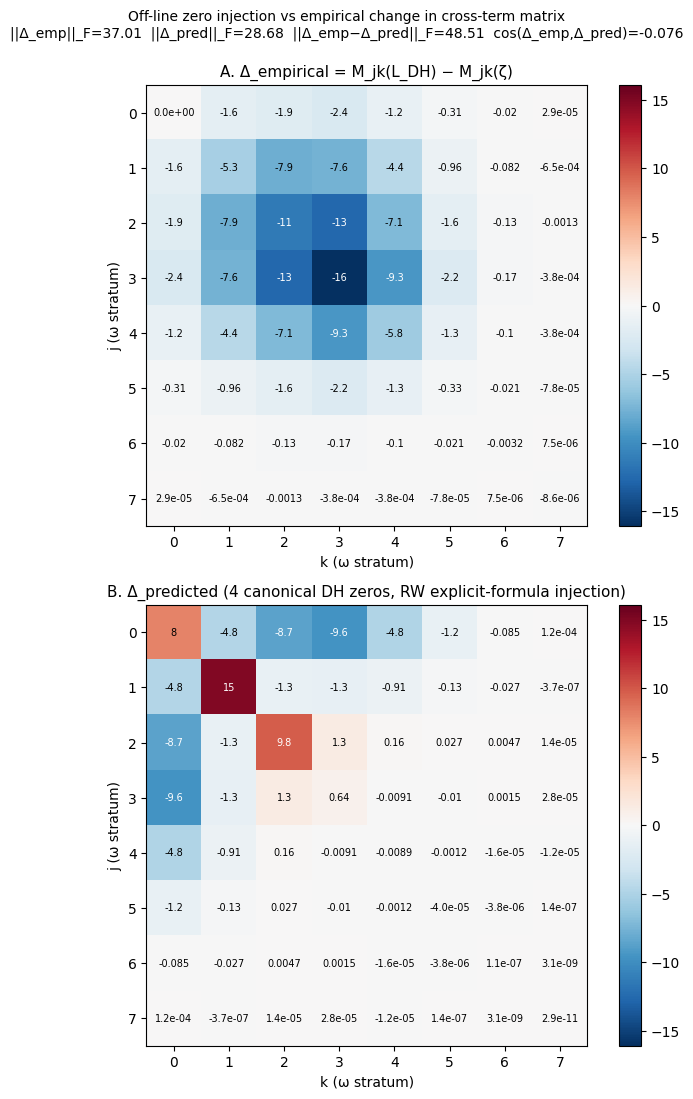

Saved figure


In [20]:
# Final figure: 2 subfigure heatmap (A: Δ_empirical; B: Δ_predicted with best regularization)
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Use Delta_pred_4 (more meaningful: full canonical zero quartet at FE-symmetric points)
Dp_fig = Delta_pred_4

vmax = max(np.abs(Delta_emp).max(), np.abs(Dp_fig).max())
norm_div = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

fig, axes = plt.subplots(2, 1, figsize=(7, 11))
labels = list(range(K))

for ax, M, title in zip(axes, [Delta_emp, Dp_fig], 
 ['A. Δ_empirical = M_jk(L_DH) − M_jk(ζ)',
 'B. Δ_predicted (4 canonical DH zeros, RW explicit-formula injection)']):
 im = ax.imshow(M, cmap='RdBu_r', norm=norm_div)
 ax.set_xticks(range(K)); ax.set_yticks(range(K))
 ax.set_xticklabels(labels); ax.set_yticklabels(labels)
 ax.set_xlabel('k (ω stratum)'); ax.set_ylabel('j (ω stratum)')
 ax.set_title(title, fontsize=11)
 for j in range(K):
 for k in range(K):
 v = M[j,k]
 txt = f"{v:.2g}" if abs(v) > 1e-3 else f"{v:.1e}"
 ax.text(k, j, txt, ha='center', va='center', fontsize=7,
 color='white' if abs(v)>vmax*0.5 else 'black')
 plt.colorbar(im, ax=ax, fraction=0.046)

fig.suptitle(
 f'Off-line zero injection vs empirical change in cross-term matrix\n'
 f'||Δ_emp||_F={fro_emp:.2f} ||Δ_pred||_F={np.linalg.norm(Dp_fig,"fro"):.2f} '
 f'||Δ_emp−Δ_pred||_F={np.linalg.norm(Delta_emp-Dp_fig,"fro"):.2f} cos(Δ_emp,Δ_pred)={cos_sim4:.3f}',
 fontsize=10, y=0.995)
plt.tight_layout()
plt.savefig('Mjk_DH_vs_zeta_prediction.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved figure")

In [21]:
from e14c.data_storage import upload
uri = upload('Sk_at_peaks_F4.npz', 'Davenport-Heilbronn (F4) ω-stratified partial sums S_k at the 200 ζ-peak t-values, N=10^6, K=8, κ=0.28408. Computed via Numba-parallel Kahan-compensated summation, with c_n periodic mod 5 and ω(n) sieved.')
print(uri)
uri2 = upload('Mjk_DH_vs_zeta_prediction.png', 'Heatmap comparing empirical Δ M_jk(L_DH)-M_jk(ζ) vs predicted change from injecting 4 canonical DH off-line zeros.')
print(uri2)

Uploaded Sk_at_peaks_F4.npz to data storage as entry data_entry:sk-at-peaks-f4-npz-td83 under the name 'Sk_at_peaks_F4.npz'.
data_entry:sk-at-peaks-f4-npz-td83


Uploaded Mjk_DH_vs_zeta_prediction.png to data storage as entry data_entry:mjk-dh-vs-zeta-prediction-png-7gtu under the name 'Mjk_DH_vs_zeta_prediction.png'.
data_entry:mjk-dh-vs-zeta-prediction-png-7gtu
